## XGB classifier for updated dataset with 26 variables
This notebook trains an XGBoost classifier to predict whether a newcomer to Ontario will be employed, using synthetic data.

### Step 1: Import Libraries

In [4]:
pip install xgboost shap

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from xgboost import XGBClassifier
import shap

### Step 2: Load the Dataset

In [6]:
# Load the newcomer dataset from the CSV file
df = pd.read_csv("newcomer_ontario_enriched.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 6900 rows and 26 columns


,age,sex,admission_category,province,world_region,speaks_official_language,education_level,family_size,field_of_study,previous_occupation,...,employed,employment_category,employment_occupation,employment_sector,occupationally_downgraded,annual_income,months_to_employment,rent_to_income_ratio,housing_affordable,affordability_score
0,35,M,Skilled Worker,Ontario,South Asia,1,University,1,Economics,HR Specialist,...,1,Sales & Service,Cashier,Accommodation & Food Services,1,21900.0,7,1.15,0,0.436
1,43,M,Skilled Worker,Ontario,South Asia,0,High School,4,General Studies,Administrative Officer,...,1,"Business, Finance & Administration",Accountant,Public Administration,0,63300.0,2,0.40,0,0.706
2,33,M,Skilled Worker,Ontario,South Asia,1,University,3,Business Administration,Administrative Officer,...,1,"Business, Finance & Administration",Administrative Officer,Professional Services,0,91400.0,2,0.28,1,0.861
3,42,M,Skilled Worker,Ontario,South Asia,1,College,3,Business Administration,Restaurant Manager,...,1,Management,Restaurant Manager,Accommodation & Food Services,0,78000.0,4,0.32,0,0.800
4,27,M,Skilled Worker,Ontario,South Asia,1,University,1,Mathematics,Mechanical Engineer,...,1,"Trades, Transport & Equipment Operators",Electrician,Construction,1,31300.0,1,0.81,0,0.511


### Step 3: Exploratory Data Analysis (EDA)

In [7]:
# Check the data types of each column
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
age                                int64
sex                               object
admission_category                object
province                          object
world_region                      object
speaks_official_language           int64
education_level                   object
family_size                        int64
field_of_study                    object
previous_occupation               object
occupation_category               object
years_of_experience                int64
teer_category                     object
credential_recognition_status     object
regulated_profession               int64
employment_probability           float64
employed                           int64
employment_category               object
employment_occupation             object
employment_sector                 object
occupationally_downgraded          int64
annual_income                    float64
months_to_employment               int64
rent_to_income_ratio             float

In [8]:
# Summary statistics for all numeric columns
print("Summary Statistics:")
df.describe()

Summary Statistics:


,age,speaks_official_language,family_size,years_of_experience,regulated_profession,employment_probability,employed,occupationally_downgraded,annual_income,months_to_employment,rent_to_income_ratio,housing_affordable,affordability_score
count,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000,6900.000000
mean,32.714058,0.721739,2.442029,7.353623,0.208406,0.781101,0.781159,0.337681,43893.115942,9.016377,0.864588,0.145217,0.547485
std,7.485434,0.448175,1.140627,5.656536,0.406198,0.136213,0.413490,0.472953,36170.535071,13.817905,0.559600,0.352345,0.228099
min,18.000000,0.000000,1.000000,0.000000,0.000000,0.474653,0.000000,0.000000,0.000000,1.000000,0.130000,0.000000,0.190000
25%,27.000000,0.000000,2.000000,3.000000,0.000000,0.633195,1.000000,0.000000,19000.000000,1.000000,0.370000,0.000000,0.341000
50%,33.000000,1.000000,2.000000,7.000000,0.000000,0.854925,1.000000,0.000000,37000.000000,4.000000,0.680000,0.000000,0.525000
75%,38.000000,1.000000,3.000000,11.000000,0.000000,0.887576,1.000000,1.000000,68400.000000,11.000000,1.330000,0.000000,0.754000
max,65.000000,1.000000,5.000000,29.000000,1.000000,0.941367,1.000000,1.000000,195500.000000,184.000000,1.750000,1.000000,0.944000


In [9]:
# Value counts for selected categorical column so we can see the spread of categories
categorical_cols = [
    "sex",
    "admission_category",
    "world_region",
    "education_level",
    "field_of_study",
    "previous_occupation",
    "occupation_category",
    "teer_category",
    "credential_recognition_status",
]

for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())


Value counts for 'sex':
sex
M    3800
F    3100
Name: count, dtype: int64

Value counts for 'admission_category':
admission_category
Skilled Worker                 2500
Canadian Experience Class      1200
Family Sponsored               1000
Government Assisted Refugee     900
Caregiver                       500
Privately Sponsored Refugee     400
Protected Person                400
Name: count, dtype: int64

Value counts for 'world_region':
world_region
South Asia        2800
Southeast Asia    1600
Africa            1300
Middle East        800
East Asia          400
Name: count, dtype: int64

Value counts for 'education_level':
education_level
University      3147
Postgraduate    1690
College         1369
High School      694
Name: count, dtype: int64

Value counts for 'field_of_study':
field_of_study
Business Administration      825
Engineering Technology       765
Manufacturing Technology     631
General Studies              549
Communications               445
Skilled Trades       

In [10]:
# Check the class balance for the target column 'employed'
# This tells us if the data is imbalanced (more employed than not, or vice versa)
print("Class balance for 'employed' column:")
print(df["employed"].value_counts())
print(f"\nPercentage breakdown:")
print(df["employed"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Class balance for 'employed' column:
employed
1    5390
0    1510
Name: count, dtype: int64

Percentage breakdown:
employed
1    78.12%
0    21.88%
Name: proportion, dtype: object


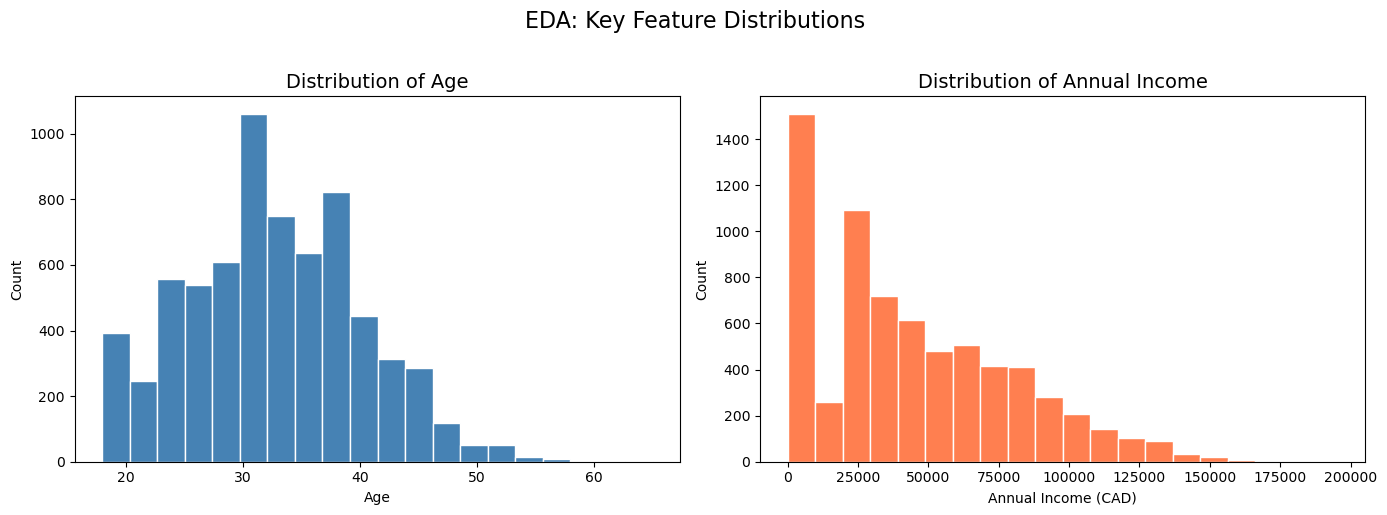

In [11]:
# Plot the distribution of age and annual_income side by side
# and save the figure to a file for reference

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(df["age"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Age", fontsize=14)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Annual income distribution
axes[1].hist(df["annual_income"], bins=20, color="coral", edgecolor="white")
axes[1].set_title("Distribution of Annual Income", fontsize=14)
axes[1].set_xlabel("Annual Income (CAD)")
axes[1].set_ylabel("Count")

plt.suptitle("EDA: Key Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 4: Preprocessing

In [12]:
# Make a copy so we do not modify the original dataframe
df_processed = df.copy()

# Drop the province column because every row is Ontario, so it adds no useful information
df_processed.drop(columns=["province"], inplace=True)

# Scope down to the 13 features selected for the classifier
classifier_features = [
    "age",
    "sex",
    "admission_category",
    "world_region",
    "speaks_official_language",
    "education_level",
    "family_size",
    "field_of_study",
    "previous_occupation",
    "years_of_experience",
    "teer_category",
    "credential_recognition_status",
    "regulated_profession",
]
Target = "employed"

df_processed = df_processed[classifier_features + [Target]]

# collapse rare categories into "Other" for the two high-cardinality features
high_cardinality_features = ["previous_occupation", "field_of_study"]
rare_threshold = 0.01  # this collapse categories below 1% frequency

rare_category_map = {}
for col in high_cardinality_features:
    freq = df_processed[col].value_counts(normalize=True)
    rare_categories = freq[freq < rare_threshold].index.tolist()
    rare_category_map[col] = rare_categories
    df_processed[col] = df_processed[col].where(~df_processed[col].isin(rare_categories), "Other")
    print(f"{col}: collapsed {len(rare_categories)} rare categories into 'Other' "
          f"-> {df_processed[col].nunique()} categories remaining")

#Label encode all 9 categorical columns
categorical_cols = [
    "sex",
    "admission_category",
    "world_region",
    "education_level",
    "field_of_study",
    "previous_occupation",
    "teer_category",
    "credential_recognition_status",
]

label_encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    df_processed[col] = encoder.fit_transform(df_processed[col])
    label_encoders[col] = encoder
    print(f"Encoded '{col}' column.")

print(f"Processed dataframe shape: {df_processed.shape}")

df_processed.head()

previous_occupation: collapsed 4 rare categories into 'Other' -> 38 categories remaining
field_of_study: collapsed 8 rare categories into 'Other' -> 27 categories remaining
Encoded 'sex' column.
Encoded 'admission_category' column.
Encoded 'world_region' column.
Encoded 'education_level' column.
Encoded 'field_of_study' column.
Encoded 'previous_occupation' column.
Encoded 'teer_category' column.
Encoded 'credential_recognition_status' column.
Processed dataframe shape: (6900, 14)


,age,sex,admission_category,world_region,speaks_official_language,education_level,family_size,field_of_study,previous_occupation,years_of_experience,teer_category,credential_recognition_status,regulated_profession,employed
0,35,1,6,3,1,3,1,4,15,8,1,2,0,1
1,43,1,6,3,0,1,4,9,1,20,1,0,0,1
2,33,1,6,3,1,3,3,1,1,2,1,0,0,1
3,42,1,6,3,1,0,3,1,29,15,0,0,0,1
4,27,1,6,3,1,3,1,17,19,2,1,1,0,1


In [13]:
#Define X and y
X = df_processed[classifier_features]
y = df_processed[Target]

print("Feature columns used for training:")
print(X.columns.tolist())
print(f"\nTotal features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

Feature columns used for training:
['age', 'sex', 'admission_category', 'world_region', 'speaks_official_language', 'education_level', 'family_size', 'field_of_study', 'previous_occupation', 'years_of_experience', 'teer_category', 'credential_recognition_status', 'regulated_profession']

Total features: 13
Total samples: 6900


For X features we droped the target and all columns that are outcomes of being employed,not predictors of it. Keeping them would cause data leakage and give unrealistically perfect scores.
Columns dropped and why:
 annual_income: you only earn income after getting a job,
 affordability_score: derived from income, so also post-employment,
 months_to_employment: measures time after getting hired, not before,
 rent_to_income_ratio: every unemployed person has exactly 1.75 (no income), making it a perfect but meaningless signal, housing_affordable: always 0 for unemployed, directly leaks the label

In [14]:
# Split the data into 80% training and 20% testing
# stratify=y ensures the class balance is preserved in both splits
# random_state=42 makes the split reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

Training set size: 5520 samples
Test set size:     1380 samples


In [15]:
# Calculate scale_pos_weight to handle class imbalance
# This tells XGBoost to pay more attention to the minority class
# Formula: number of negative cases / number of positive cases

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Negative (not employed) count: {neg_count}")
print(f"Positive (employed) count:     {pos_count}")
print(f"scale_pos_weight set to:       {scale_pos_weight:.4f}")

# Train the XGBoost classifier
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
)

model.fit(X_train, y_train)

Negative (not employed) count: 1208
Positive (employed) count:     4312
scale_pos_weight set to:       0.2801


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

### Step 7: Evaluate the Model

In [22]:
# Make predictions on the test set
from sklearn.metrics import precision_score, recall_score


y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability scores for the positive class

# Print core evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:  {recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Employed", "Employed"]))

Accuracy:  0.7051
F1 Score:  0.8046
Precision:  0.8338
Recall:  0.7774

Classification Report:
              precision    recall  f1-score   support

Not Employed       0.36      0.45      0.40       302
    Employed       0.83      0.78      0.80      1078

    accuracy                           0.71      1380
   macro avg       0.60      0.61      0.60      1380
weighted avg       0.73      0.71      0.72      1380



In [17]:
# Print the confusion matrix
# Rows are actual labels, columns are predicted labels
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                Predicted Not Employed   Predicted Employed")
print(f"Actual Not Employed        {cm[0][0]:<22} {cm[0][1]}")
print(f"Actual Employed            {cm[1][0]:<22} {cm[1][1]}")

Confusion Matrix:
                Predicted Not Employed   Predicted Employed
Actual Not Employed        135                    167
Actual Employed            240                    838


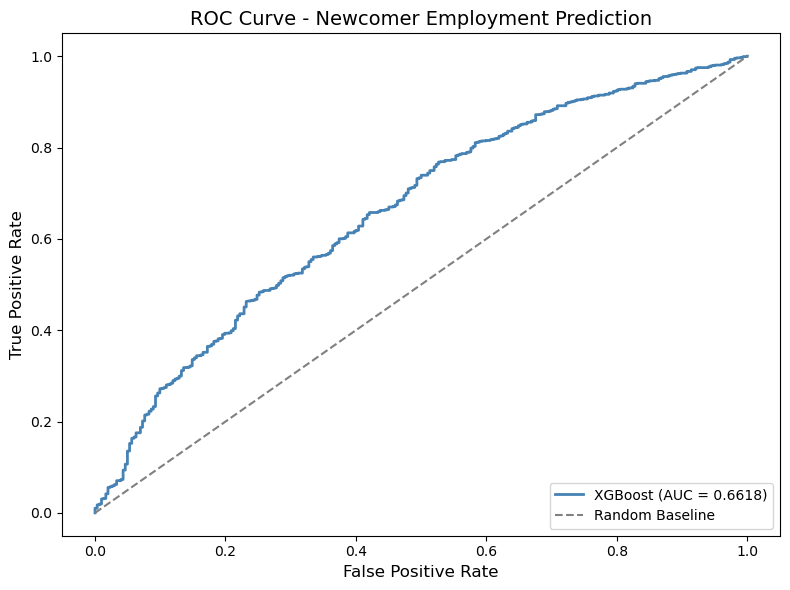

In [18]:
# Plot and save the ROC curve
# The ROC curve shows the tradeoff between true positive rate and false positive rate
# A higher AUC (area under the curve) means a better model

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"XGBoost (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Baseline")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Newcomer Employment Prediction", fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

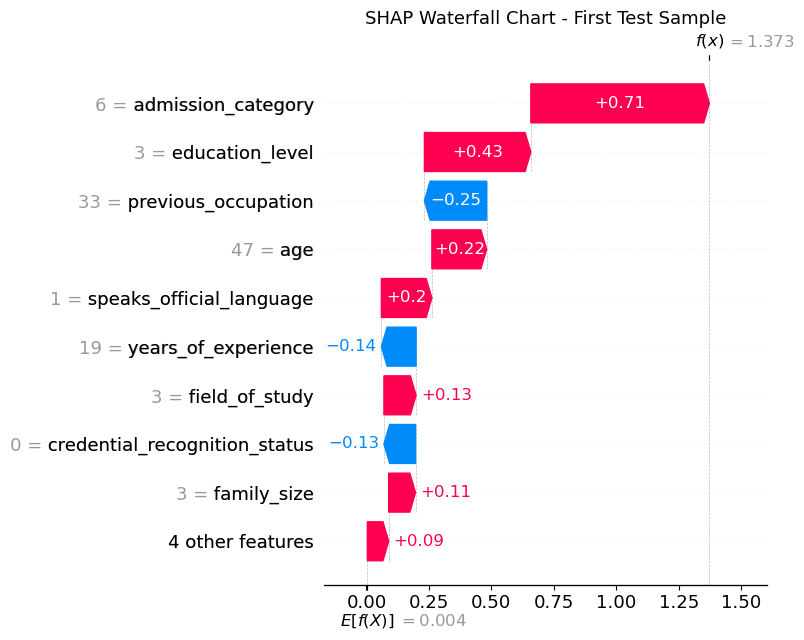

In [19]:
# SHAP (SHapley Additive exPlanations) waterfall chart for the first test sample
# SHAP explains WHY the model made a specific prediction by showing the contribution
# of each feature to the final output for that one sample

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Waterfall plot for the very first test sample
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Waterfall Chart - First Test Sample", fontsize=13)
plt.tight_layout()
plt.savefig("shap_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 8: Save the Trained Model

In [20]:
# Create the models folder if it does not already exist
os.makedirs("models", exist_ok=True)

# Save the trained model to disk using joblib
# This lets us reload the model later without retraining it from scratch
model_path = "Secondversion_XGB_classifier.pkl"
joblib.dump(model, model_path)

['Secondversion_XGB_classifier.pkl']